In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Зчитуємо файли прямо з вашої папки (назви точнісінько як на скриншоті image_b1f862.png)
df_payments = pd.read_csv("payments_encrypted.csv")
df_registrations = pd.read_csv("registrations_encrypted (1).csv")
df_splits = pd.read_csv("splits_encrypted.csv")

# Перетворюємо колонки з датами у правильний формат datetime
df_payments['date_created'] = pd.to_datetime(df_payments['date_created'])
# Створюємо чисту колонку з датою (без часу) для агрегації по днях
df_payments['day'] = df_payments['date_created'].dt.date

# Глобальна дата збою для графіків
OUTAGE = pd.Timestamp('2024-05-16')

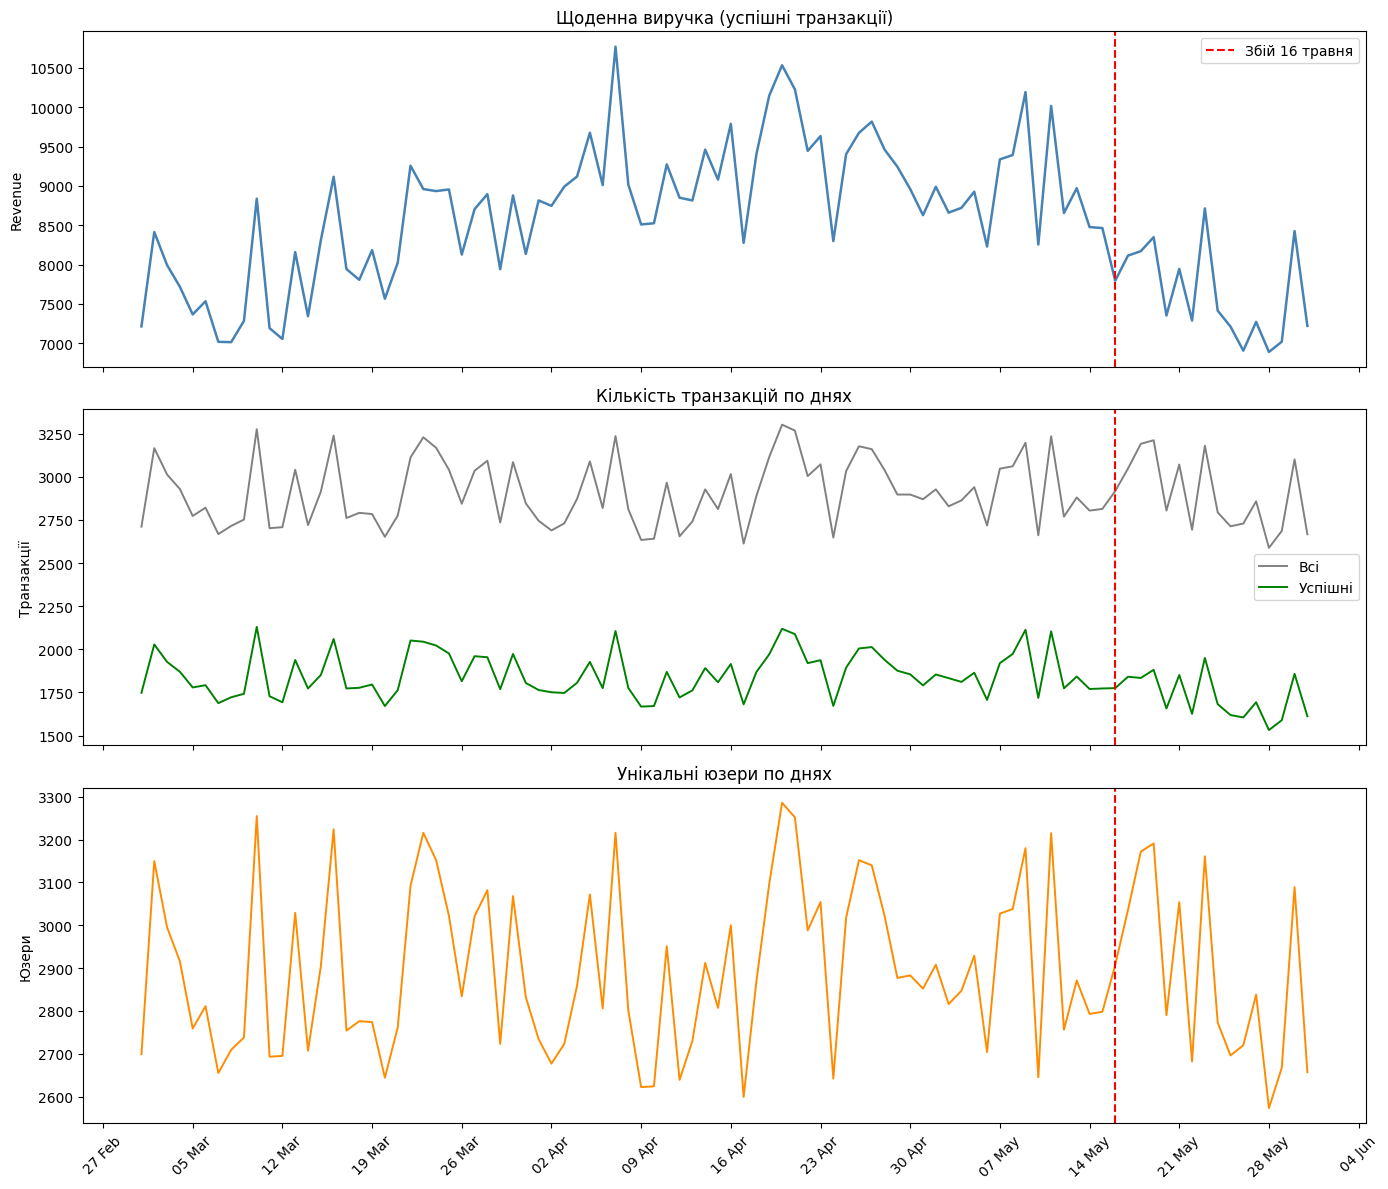

In [2]:
# Агрегуємо дані по днях (заміна першого SQL-запиту)
df_revenue = df_payments.groupby('day').agg(
    total_transactions=('id_order', 'count'),
    successful_transactions=('status', lambda x: (x == 'success').sum()),
    revenue=('amount_original', lambda x: df_payments.loc[x.index].loc[df_payments['status'] == 'success', 'amount_original'].sum()),
    unique_users=('id_user', 'nunique')
).reset_index()

# Округлюємо виручку та приводимо дату до Timestamp для графіків
df_revenue['revenue'] = df_revenue['revenue'].round(2)
df_revenue['day'] = pd.to_datetime(df_revenue['day'])

# ── Графік ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Виручка
axes[0].plot(df_revenue['day'], df_revenue['revenue'], color='steelblue', linewidth=1.8)
axes[0].axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій 16 травня')
axes[0].set_title('Щоденна виручка (успішні транзакції)')
axes[0].set_ylabel('Revenue')
axes[0].legend()

# 2. Кількість транзакцій
axes[1].plot(df_revenue['day'], df_revenue['total_transactions'], label='Всі', color='gray', linewidth=1.4)
axes[1].plot(df_revenue['day'], df_revenue['successful_transactions'], label='Успішні', color='green', linewidth=1.4)
axes[1].axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Кількість транзакцій по днях')
axes[1].set_ylabel('Транзакції')
axes[1].legend()

# 3. Унікальні юзери
axes[2].plot(df_revenue['day'], df_revenue['unique_users'], color='darkorange', linewidth=1.4)
axes[2].axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Унікальні юзери по днях')
axes[2].set_ylabel('Юзери')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Доступні статуси у вашому файлі: ['fail', 'success']
⚠️ Статус 'failed' не знайдено. Побудовано графік для статусу: 'fail'


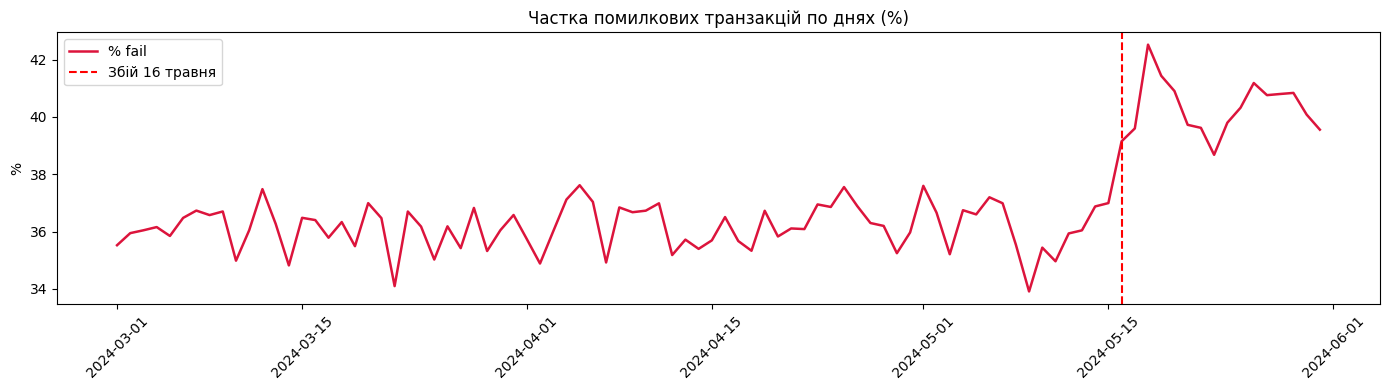

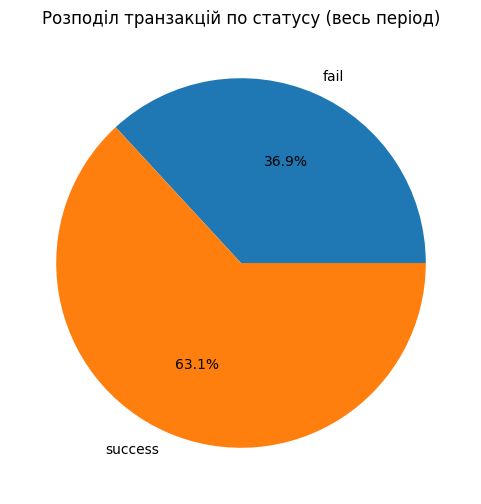

In [3]:
# 1. Приводимо всі статуси до нижнього регістру, щоб уникнути проблем із 'Failed' / 'failed'
df_payments['status'] = df_payments['status'].astype(str).str.lower()

# 2. Перераховуємо групування
df_status = df_payments.groupby(['day', 'status']).agg(
    cnt=('id_order', 'count'),
    total_amount=('amount_original', 'sum')
).reset_index()

df_status['total_amount'] = df_status['total_amount'].round(2)
df_status['day'] = pd.to_datetime(df_status['day'])

# 3. Робимо Pivot
pivot = df_status.pivot_table(index='day', columns='status', values='cnt', aggfunc='sum').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# ── Графік: частка failed по днях ───────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Перевіряємо, які взагалі статуси є в таблиці, щоб не гадати
print("Доступні статуси у вашому файлі:", list(pivot_pct.columns))

if 'failed' in pivot_pct.columns:
    ax.plot(pivot_pct.index, pivot_pct['failed'], color='crimson', linewidth=1.8, label='% failed')
else:
    # Якщо статус називається інакше, спробуємо вивести перший ліпший нестандартний статус (наприклад, 'error' або 'declined')
    alternative_statuses = [col for col in pivot_pct.columns if col != 'success']
    if alternative_statuses:
        target_status = alternative_statuses[0]
        ax.plot(pivot_pct.index, pivot_pct[target_status], color='crimson', linewidth=1.8, label=f'% {target_status}')
        print(f"⚠️ Статус 'failed' не знайдено. Побудовано графік для статусу: '{target_status}'")

ax.axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій 16 травня')
ax.set_title('Частка помилкових транзакцій по днях (%)')
ax.set_ylabel('%')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Загальний розподіл (pie) ─────────────────────────────
status_total = df_status.groupby('status')['cnt'].sum()
plt.figure(figsize=(6, 6))
status_total.plot.pie(autopct='%1.1f%%', title='Розподіл транзакцій по статусу (весь період)')
plt.ylabel('')
plt.show()

=== Аномалії в таблиці Payments ===
                     значення
duplicate_orders            0
null_id_user                0
null_date                   0
null_amount                 0
null_status                 0
non_positive_amount     98599
future_dates                0
total_rows             267466


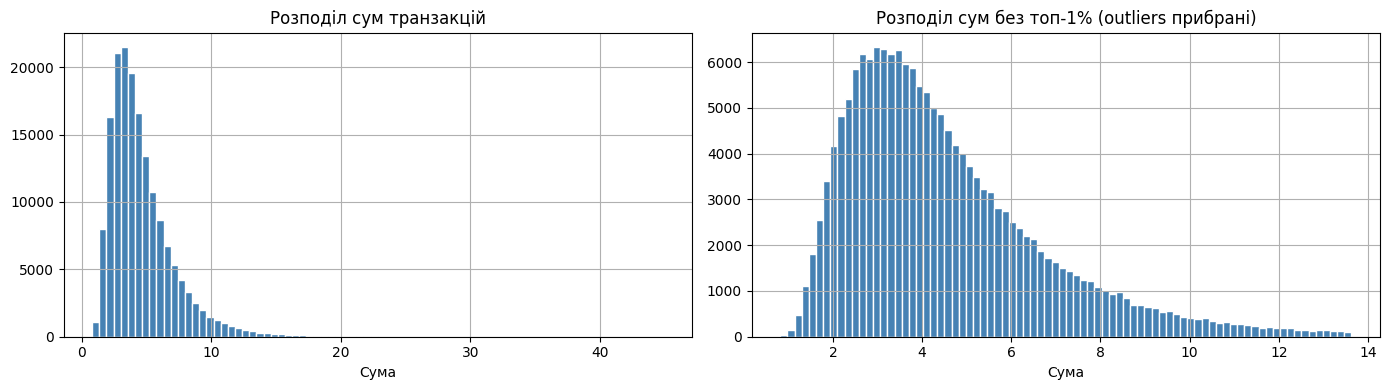

count    168867.000000
mean          4.647624
std           2.546201
min           0.820000
25%           2.920000
50%           4.030000
75%           5.680000
95%           9.440000
99%          13.633400
max          44.890000
Name: amount_original, dtype: float64


In [4]:
import datetime

# Розрахунок аномалій засобами Pandas
anomalies = {
    'duplicate_orders': df_payments['id_order'].count() - df_payments['id_order'].nunique(),
    'null_id_user': df_payments['id_user'].isna().sum(),
    'null_date': df_payments['date_created'].isna().sum(),
    'null_amount': df_payments['amount_original'].isna().sum(),
    'null_status': df_payments['status'].isna().sum(),
    'non_positive_amount': (df_payments['amount_original'] <= 0).sum(),
    'future_dates': (df_payments['day'] > datetime.date.today()).sum(),
    'total_rows': len(df_payments)
}

df_anomaly = pd.DataFrame.from_dict(anomalies, orient='index', columns=['значення'])
print("=== Аномалії в таблиці Payments ===")
print(df_anomaly)

# ── Розподіл сум транзакцій (виявлення outliers) ────────
df_amounts = df_payments[(df_payments['status'] == 'success') & (df_payments['amount_original'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_amounts['amount_original'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Розподіл сум транзакцій')
axes[0].set_xlabel('Сума')

# Без топ-1% для кращої видимості
cap = df_amounts['amount_original'].quantile(0.99)
df_amounts[df_amounts['amount_original'] <= cap]['amount_original'].hist(
    bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Розподіл сум без топ-1% (outliers прибрані)')
axes[1].set_xlabel('Сума')

plt.tight_layout()
plt.show()

print(df_amounts['amount_original'].describe(percentiles=[.25, .5, .75, .95, .99]))

Виручка по сплітах

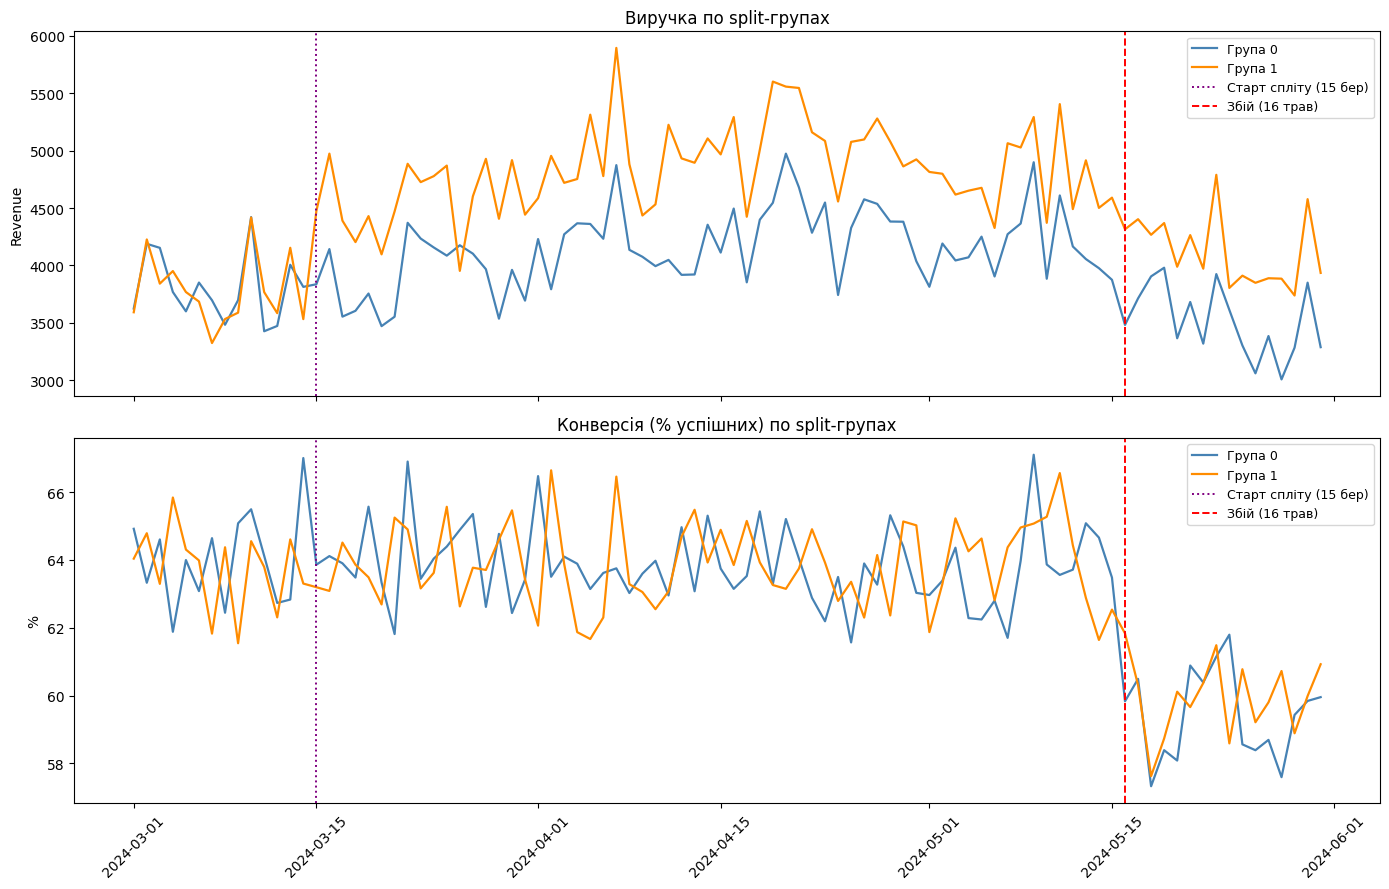

=== Підсумок по split-групах (весь період) ===
             total_revenue  total_users  total_transactions  ARPU
split_group                                                      
0                366322.77       132771              133455  2.76
1                418507.58       133357              134011  3.14


In [5]:

# Об'єднуємо платежі зі сплітами по id_user
df_split_raw = pd.merge(df_payments, df_splits, on='id_user', how='inner')

# Агрегація даних (заміна SQL-запиту)
df_split = df_split_raw.groupby(['day', 'split_group']).agg(
    transactions=('id_order', 'count'),
    successful=('status', lambda x: (x == 'success').sum()),
    revenue=('amount_original', lambda x: df_split_raw.loc[x.index].loc[df_split_raw['status'] == 'success', 'amount_original'].sum()),
    unique_users=('id_user', 'nunique')
).reset_index()

df_split['revenue'] = df_split['revenue'].round(2)
df_split['day'] = pd.to_datetime(df_split['day'])

# ── Виручка по групах ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Обробляємо групи, які є в даних (зазвичай 0 та 1)
for group in sorted(df_split['split_group'].unique()):
    color = 'steelblue' if group == 0 else 'darkorange'
    subset = df_split[df_split['split_group'] == group]
    
    axes[0].plot(subset['day'], subset['revenue'],
                 label=f'Група {group}', color=color, linewidth=1.6)
    axes[1].plot(subset['day'], subset['successful'] / subset['transactions'] * 100,
                 label=f'Група {group}', color=color, linewidth=1.6)

for ax in axes:
    ax.axvline(pd.Timestamp('2024-03-15'), color='purple',
               linestyle=':', linewidth=1.4, label='Старт спліту (15 бер)')
    ax.axvline(OUTAGE, color='red',
               linestyle='--', linewidth=1.4, label='Збій (16 трав)')
    ax.legend(fontsize=9)

axes[0].set_title('Виручка по split-групах')
axes[0].set_ylabel('Revenue')
axes[1].set_title('Конверсія (% успішних) по split-групах')
axes[1].set_ylabel('%')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Загальний розмір груп і ARPU ────────────────────────
summary_split = df_split.groupby('split_group').agg(
    total_revenue=('revenue', 'sum'),
    total_users=('unique_users', 'sum'),
    total_transactions=('transactions', 'sum')
).assign(ARPU=lambda x: x['total_revenue'] / x['total_users'])

print("=== Підсумок по split-групах (весь період) ===")
print(summary_split.round(2))

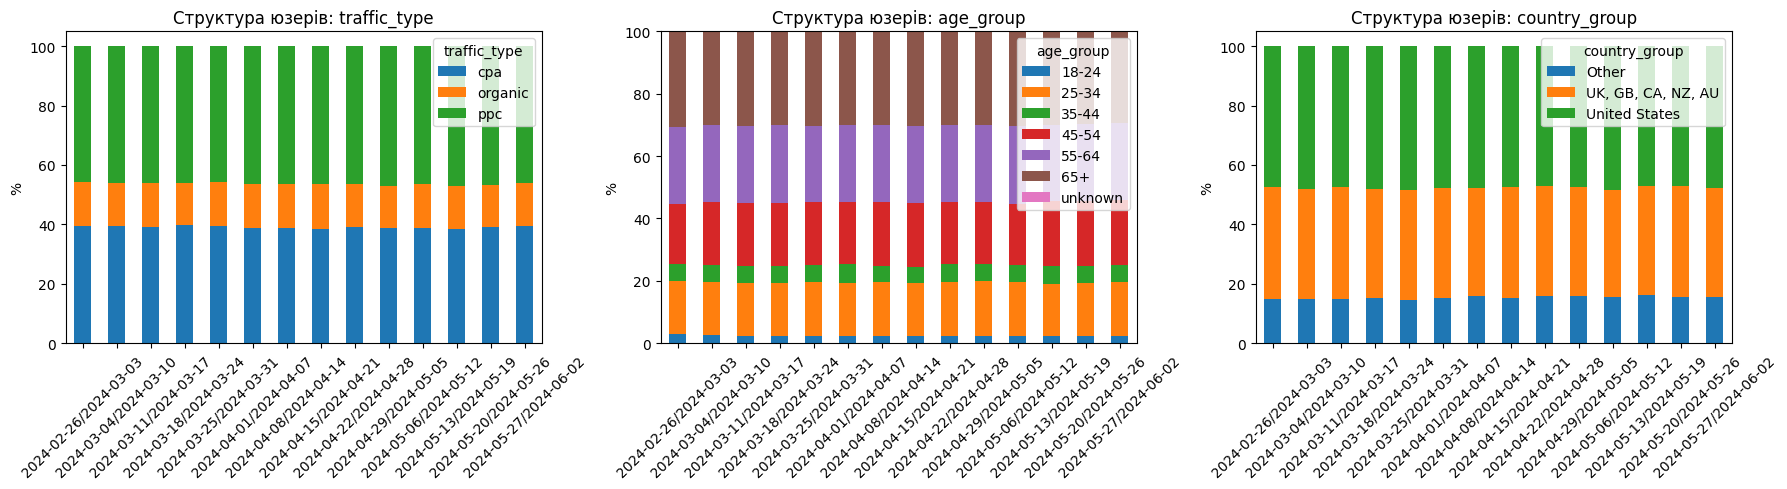

In [6]:
# Об'єднуємо платежі з реєстраціями
df_mix_raw = pd.merge(df_payments, df_registrations, on='id_user', how='inner')

# Агрегуємо
df_mix = df_mix_raw.groupby(['day', 'traffic_type', 'gender', 'age_group', 'country_group']).agg(
    users=('id_user', 'nunique'),
    revenue=('amount_original', lambda x: df_mix_raw.loc[x.index].loc[df_mix_raw['status'] == 'success', 'amount_original'].sum())
).reset_index()

df_mix['revenue'] = df_mix['revenue'].round(2)
df_mix['day'] = pd.to_datetime(df_mix['day'])

# ── Частка по тижнях ───────────────────────
df_mix['week'] = df_mix['day'].dt.to_period('W').astype(str)  # перетворюємо в string для коректного рендерингу барів

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['traffic_type', 'age_group', 'country_group']):
    pivot = (df_mix.groupby(['week', col])['users']
             .sum()
             .unstack(fill_value=0))
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct.plot(kind='bar', stacked=True, ax=ax, legend=True)
    ax.set_title(f'Структура юзерів: {col}')
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

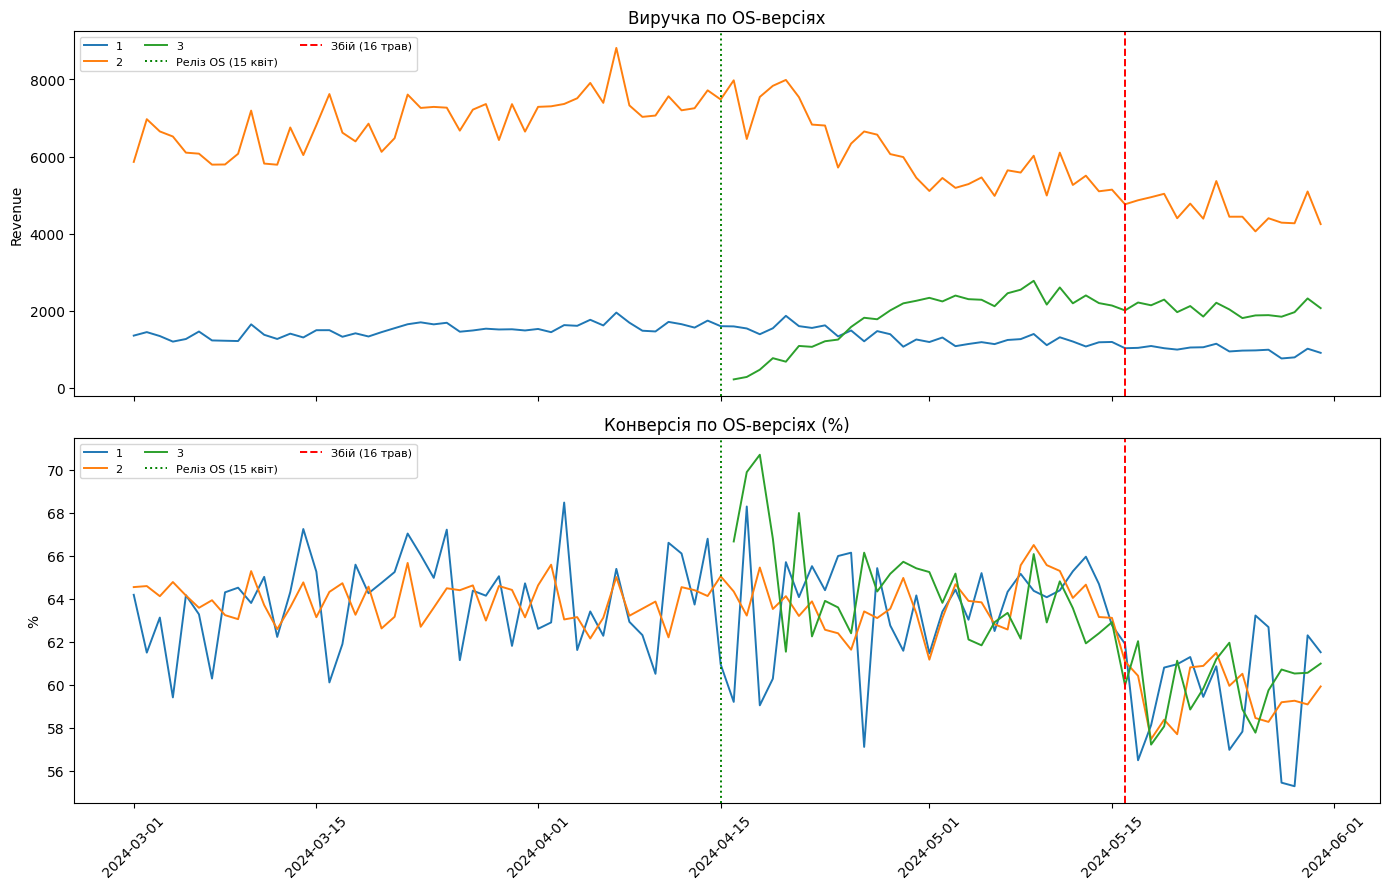

In [7]:
# Агрегація суто по колонці os_version, яка вже є в df_payments
df_os = df_payments.groupby(['day', 'os_version']).agg(
    transactions=('id_order', 'count'),
    successful=('status', lambda x: (x == 'success').sum()),
    revenue=('amount_original', lambda x: df_payments.loc[x.index].loc[df_payments['status'] == 'success', 'amount_original'].sum())
).reset_index()

df_os['revenue'] = df_os['revenue'].round(2)
df_os['day'] = pd.to_datetime(df_os['day'])
df_os['conversion'] = df_os['successful'] / df_os['transactions'] * 100

# ── Конверсія по OS-версіях ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for os_ver, grp in df_os.groupby('os_version'):
    axes[0].plot(grp['day'], grp['revenue'], label=str(os_ver), linewidth=1.4)
    axes[1].plot(grp['day'], grp['conversion'], label=str(os_ver), linewidth=1.4)

for ax in axes:
    ax.axvline(pd.Timestamp('2024-04-15'), color='green',
               linestyle=':', linewidth=1.4, label='Реліз OS (15 квіт)')
    ax.axvline(OUTAGE, color='red',
               linestyle='--', linewidth=1.4, label='Збій (16 трав)')
    ax.legend(fontsize=8, ncol=3)

axes[0].set_title('Виручка по OS-версіях')
axes[0].set_ylabel('Revenue')
axes[1].set_title('Конверсія по OS-версіях (%)')
axes[1].set_ylabel('%')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

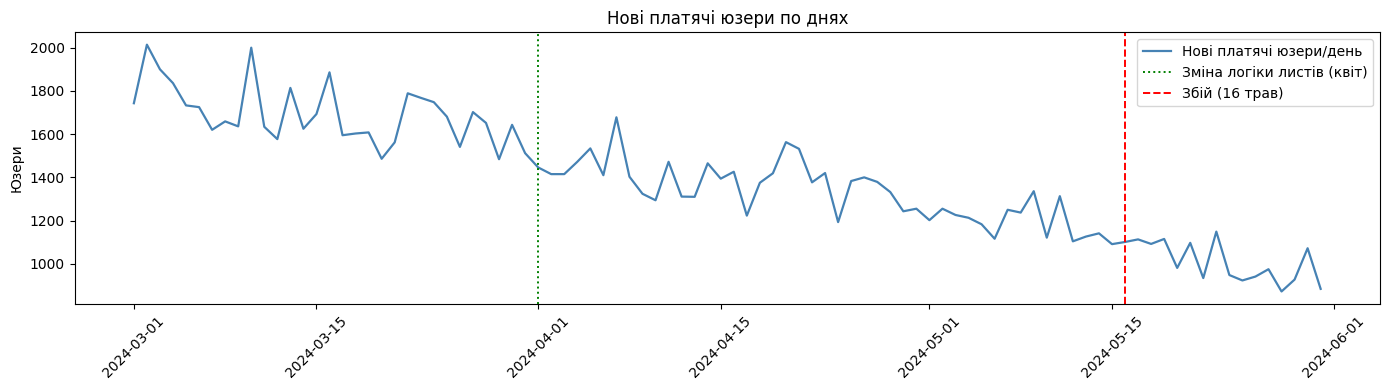

In [8]:
# 1. Знаходимо дату першого успішного платежу для кожного юзера (заміна CTE first_payment)
success_payments = df_payments[df_payments['status'] == 'success'].copy()
first_pay = success_payments.groupby('id_user')['day'].min().reset_index()
first_pay.columns = ['id_user', 'first_pay_date']

# 2. Об'єднуємо назад з успішними платежами, щоб залишити тільки транзакції в день першої оплати
df_cohort_raw = pd.merge(success_payments, first_pay, on='id_user', how='inner')
df_first_day_payments = df_cohort_raw[df_cohort_raw['day'] == df_cohort_raw['first_pay_date']]

# 3. Рахуємо кількість нових платячих та виручку по них
df_new = df_first_day_payments.groupby('first_pay_date').agg(
    new_paying_users=('id_user', 'nunique'),
    first_payment_revenue=('amount_original', 'sum')
).reset_index()

df_new.columns = ['day', 'new_paying_users', 'first_payment_revenue']
df_new['day'] = pd.to_datetime(df_new['day'])
df_new = df_new.sort_values('day')

# ── Графік нових платячих користувачів ──────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_new['day'], df_new['new_paying_users'], color='steelblue', linewidth=1.6, label='Нові платячі юзери/день')
ax.axvline(pd.Timestamp('2024-04-01'), color='green',
           linestyle=':', linewidth=1.4, label='Зміна логіки листів (квіт)')
ax.axvline(OUTAGE, color='red',
           linestyle='--', linewidth=1.4, label='Збій (16 трав)')
ax.set_title('Нові платячі юзери по днях')
ax.set_ylabel('Юзери')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
confounders = {
    'Фактор': [
        'Спліт-тест (15 бер)',
        'Зменшення команди підтримки (кін. бер)',
        'Зміна логіки листів (поч. квіт)',
        'Реліз нової OS (сер. квіт)',
        'Зміна структури юзерів / рекламний бюджет',
    ],
    'Чи помітний вплив?': ['?'] * 5,   # заповните вручну після аналізу графіків
    'Напрямок': ['?'] * 5,
    'Потрібно враховувати у baseline': ['?'] * 5,
}

df_confounders = pd.DataFrame(confounders)
print("=== Таблиця супутніх факторів (Confounders) ===")
print(df_confounders.to_string(index=False))

=== Таблиця супутніх факторів (Confounders) ===
                                   Фактор Чи помітний вплив? Напрямок Потрібно враховувати у baseline
                      Спліт-тест (15 бер)                  ?        ?                               ?
   Зменшення команди підтримки (кін. бер)                  ?        ?                               ?
          Зміна логіки листів (поч. квіт)                  ?        ?                               ?
               Реліз нової OS (сер. квіт)                  ?        ?                               ?
Зміна структури юзерів / рекламний бюджет                  ?        ?                               ?


In [10]:
# Копіюємо дані та примусово перетворюємо індекс на правильний формат Datetime
df_rev = df_revenue.copy()
df_rev['day'] = pd.to_datetime(df_rev['day'])
df_rev = df_rev.set_index('day').sort_index()

# Межі аналізу
OUTAGE    = pd.Timestamp('2024-05-16')
PRE_START = pd.Timestamp('2024-03-01')   # старт спліту — беремо від нього
PRE_END   = pd.Timestamp('2024-05-15')   # день до збою включно
POST_END  = pd.Timestamp('2024-06-04')   # кінець даних

pre  = df_rev.loc[PRE_START:PRE_END, 'revenue']
post = df_rev.loc[OUTAGE:POST_END,   'revenue']

print(f"Pre-period:  {len(pre)} днів, середня виручка: {pre.mean():.0f}")
print(f"Post-period: {len(post)} днів, середня виручка: {post.mean():.0f}")

Pre-period:  76 днів, середня виручка: 8720
Post-period: 16 днів, середня виручка: 7631


In [11]:
import numpy as np
from scipy import stats

df_rev['day_of_week'] = df_rev.index.dayofweek

# Середня виручка по днях тижня в pre-period
dow_avg = (df_rev.loc[PRE_START:PRE_END]
           .groupby('day_of_week')['revenue']
           .mean()
           .rename('dow_baseline'))

# Очищуємо старі колонки, якщо вони були, щоб уникнути дублікатів при повторному запуску
if 'dow_baseline' in df_rev.columns:
    df_rev = df_rev.drop(columns=['dow_baseline'])

df_rev = df_rev.join(dow_avg, on='day_of_week')

# Рахуємо rolling-середнє за 14 днів до кожної дати
df_rev['rolling_baseline'] = (df_rev['revenue']
                              .shift(1) # не включаємо поточний день
                              .rolling(14, min_periods=7)
                              .mean())

print("Rolling baseline готовий")
print(df_rev[['revenue', 'dow_baseline', 'rolling_baseline']].tail(20))

Rolling baseline готовий
            revenue  dow_baseline  rolling_baseline
day                                                
2024-05-12  8655.16   9030.937273       9071.845714
2024-05-13  8970.74   8588.155455       9014.284286
2024-05-14  8476.47   8561.930000       8994.830000
2024-05-15  8464.20   8412.344545       8960.307857
2024-05-16  7795.23   8766.170000       8948.627143
2024-05-17  8114.25   8635.710000       8863.358571
2024-05-18  8170.44   9050.925455       8824.388571
2024-05-19  8348.04   9030.937273       8785.074286
2024-05-20  7352.52   8588.155455       8743.782857
2024-05-21  7944.28   8561.930000       8681.157143
2024-05-22  7288.63   8412.344545       8581.744286
2024-05-23  8713.22   8766.170000       8431.504286
2024-05-24  7414.72   8635.710000       8325.889286
2024-05-25  7212.21   9050.925455       8265.915714
2024-05-26  6906.63   9030.937273       8065.722143
2024-05-27  7271.58   8588.155455       7940.827143
2024-05-28  6889.95   8561.930000      

In [12]:
# Числовий індекс для регресії
pre_df = df_rev.loc[PRE_START:PRE_END, ['revenue']].copy()
pre_df['t'] = np.arange(len(pre_df))

slope, intercept, r, p, se = stats.linregress(pre_df['t'], pre_df['revenue'])
print(f"Тренд: {slope:+.1f} revenue/день | R²={r**2:.3f} | p={p:.4f}")

# Екстраполюємо на post-period
post_df = df_rev.loc[OUTAGE:POST_END, ['revenue']].copy()
post_df['t'] = np.arange(len(pre_df), len(pre_df) + len(post_df))
post_df['trend_baseline'] = intercept + slope * post_df['t']

# Об'єднуємо для графіку
pre_df['trend_baseline'] = intercept + slope * pre_df['t']
all_trend = pd.concat([pre_df[['revenue','trend_baseline']], 
                       post_df[['revenue','trend_baseline']]])

Тренд: +22.9 revenue/день | R²=0.353 | p=0.0000


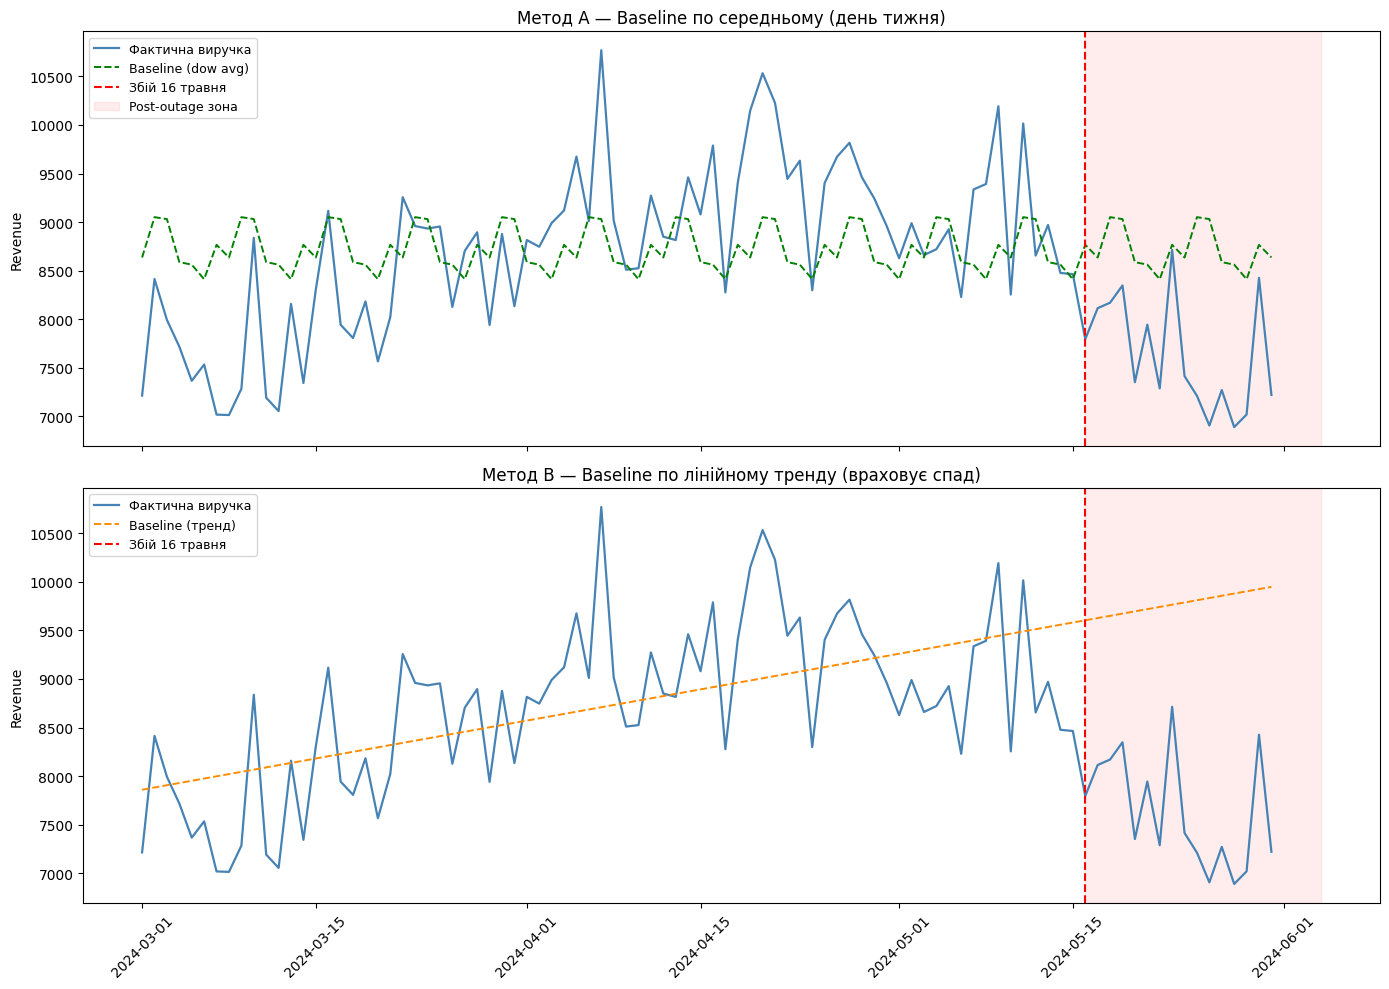

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Фільтруємо df_rev суто під наш досліджуваний проміжок для гарного графіку
df_rev_filtered = df_rev.loc[PRE_START:POST_END]

# ── Метод A ─────────────────────────────────────────────
ax = axes[0]
ax.plot(df_rev_filtered.index, df_rev_filtered['revenue'],
        color='steelblue', linewidth=1.6, label='Фактична виручка')
ax.plot(df_rev_filtered.index, df_rev_filtered['dow_baseline'],
        color='green', linestyle='--', linewidth=1.4, label='Baseline (dow avg)')
ax.axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій 16 травня')
ax.axvspan(OUTAGE, POST_END, alpha=0.07, color='red', label='Post-outage зона')
ax.set_title('Метод A — Baseline по середньому (день тижня)')
ax.set_ylabel('Revenue')
ax.legend(fontsize=9)

# ── Метод B ─────────────────────────────────────────────
ax = axes[1]
ax.plot(all_trend.index, all_trend['revenue'],
        color='steelblue', linewidth=1.6, label='Фактична виручка')
ax.plot(all_trend.index, all_trend['trend_baseline'],
        color='darkorange', linestyle='--', linewidth=1.4, label='Baseline (тренд)')
ax.axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій 16 травня')
ax.axvspan(OUTAGE, POST_END, alpha=0.07, color='red')
ax.set_title('Метод B — Baseline по лінійному тренду (враховує спад)')
ax.set_ylabel('Revenue')
ax.legend(fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Межі аналізу
PRE_SHORT_START = pd.Timestamp('2024-04-22')   # 3.5 тижні до збою
PRE_END         = pd.Timestamp('2024-05-15')

pre_short = df_rev.loc[PRE_SHORT_START:PRE_END, ['revenue']].copy()
pre_short['t'] = np.arange(len(pre_short))

slope2, intercept2, r2, p2, se2 = stats.linregress(
    pre_short['t'], pre_short['revenue'])

print(f"Короткий тренд: {slope2:+.1f} revenue/день | R²={r2**2:.3f} | p={p2:.4f}")

# Екстраполяція на post-period
post_df2 = df_rev.loc[OUTAGE:POST_END, ['revenue']].copy()
post_df2['t'] = np.arange(len(pre_short), len(pre_short) + len(post_df2))
post_df2['trend_baseline_short'] = intercept2 + slope2 * post_df2['t']

Короткий тренд: -22.6 revenue/день | R²=0.080 | p=0.1815


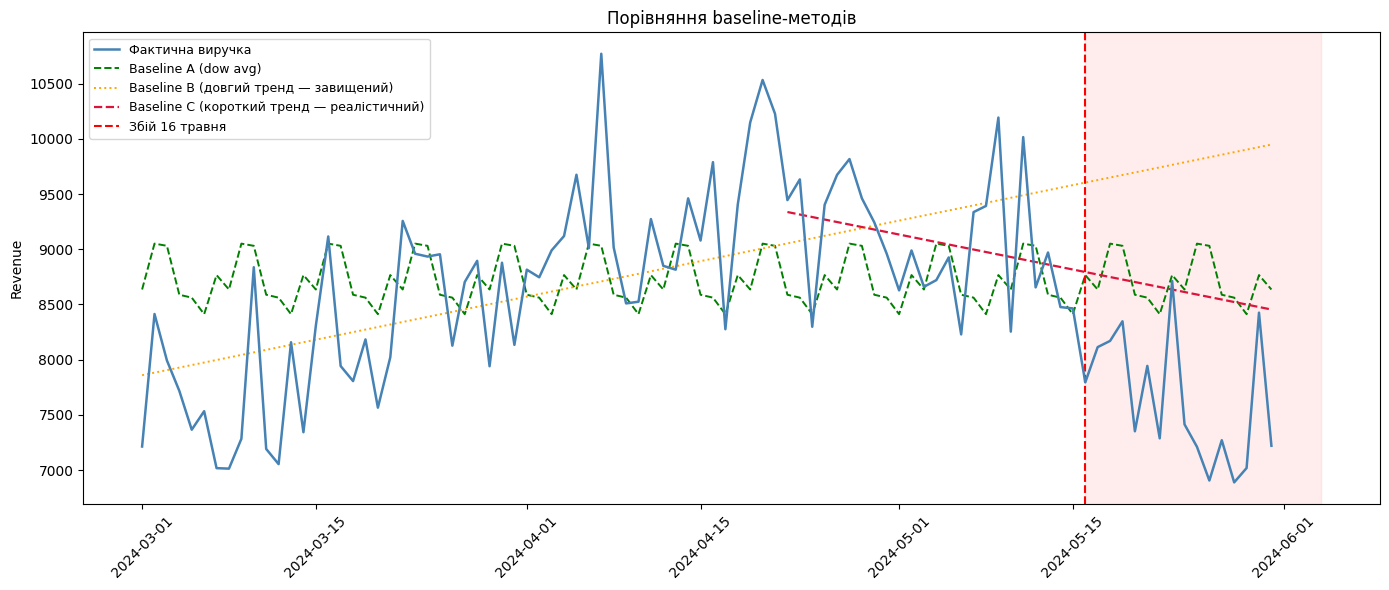

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

# Обмежуємо загальний графік рамками дослідження для кращого масштабу
df_rev_plot = df_rev.loc[PRE_START:POST_END]

# 1. Фактична виручка
ax.plot(df_rev_plot.index, df_rev_plot['revenue'],
        color='steelblue', linewidth=1.8, label='Фактична виручка', zorder=5)

# 2. Метод A — dow avg baseline
ax.plot(df_rev_plot.index, df_rev_plot['dow_baseline'],
        color='green', linestyle='--', linewidth=1.4, label='Baseline A (dow avg)')

# 3. Метод B — довгий тренд (з Блоку 3)
ax.plot(all_trend.index, all_trend['trend_baseline'],
        color='orange', linestyle=':', linewidth=1.4,
        label='Baseline B (довгий тренд — завищений)')

# 4. Метод C — короткий тренд (Блок 6)
# Рахуємо тренд на докризових датах, використовуючи їхні рідні індекси
pre_short_trend = intercept2 + slope2 * pre_short['t']

# Об'єднуємо індекси (дати) та списки значень тренду
combined_dates = list(pre_short.index) + list(post_df2.index)
combined_trends = list(pre_short_trend) + list(post_df2['trend_baseline_short'])

ax.plot(combined_dates, combined_trends,
        color='crimson', linestyle='--', linewidth=1.6,
        label='Baseline C (короткий тренд — реалістичний)')

# Візуальне оформлення
ax.axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій 16 травня')
ax.axvspan(OUTAGE, POST_END, alpha=0.07, color='red')
ax.set_title('Порівняння baseline-методів')
ax.set_ylabel('Revenue')
ax.legend(fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
post_actual        = df_rev.loc[OUTAGE:POST_END, 'revenue'].sum()
post_baseline_A    = df_rev.loc[OUTAGE:POST_END, 'dow_baseline'].sum()
post_baseline_B    = post_df['trend_baseline'].sum()          # довгий
post_baseline_C    = post_df2['trend_baseline_short'].sum()   # короткий

results = pd.DataFrame({
    'Метод': [
        'A — dow avg (нейтральний)',
        'B — довгий тренд (завищений ⚠️)',
        'C — короткий тренд (реалістичний ✅)'
    ],
    'Baseline (сума)': [post_baseline_A, post_baseline_B, post_baseline_C],
    'Факт (сума)':     [post_actual] * 3,
    'Розрив (абс)':    [post_baseline_A - post_actual,
                        post_baseline_B - post_actual,
                        post_baseline_C - post_actual],
})

results['Розрив (%)'] = (results['Розрив (абс)'] / results['Baseline (сума)'] * 100).round(1)
results[['Baseline (сума)', 'Fact (сума)', 'Розрив (абс)']] = \
    results[['Baseline (сума)', 'Факт (сума)', 'Розрив (абс)']].round(0)

print(results.to_string(index=False))

# Фінальний діапазон (між нейтральним А та реалістичним С)
low  = min(post_baseline_C - post_actual, post_baseline_A - post_actual)
high = max(post_baseline_C - post_actual, post_baseline_A - post_actual)
avg  = (low + high) / 2

print(f"\n{'='*50}")
print(f"  Середня фактична виручка/день (post): {post_actual/len(post_df2):.0f}")
print(f"  Очікувана (Baseline C) /день:          {post_baseline_C/len(post_df2):.0f}")
print(f"  Діапазон загальних втрат:  {low:,.0f} – {high:,.0f}")
print(f"  Найкраща оцінка (середня): {avg:,.0f}")
print(f"  Середні втрати на день:    {avg/len(post_df2):,.0f}")
print(f"{'='*50}")

                              Метод  Baseline (сума)  Факт (сума)  Розрив (абс)  Розрив (%)  Fact (сума)
          A — dow avg (нейтральний)         139494.0    122088.62       17406.0        12.5     122089.0
    B — довгий тренд (завищений ⚠️)         156406.0    122088.62       34318.0        21.9     122089.0
C — короткий тренд (реалістичний ✅)         137987.0    122088.62       15898.0        11.5     122089.0

  Середня фактична виручка/день (post): 7631
  Очікувана (Baseline C) /день:          8624
  Діапазон загальних втрат:  15,898 – 17,406
  Найкраща оцінка (середня): 16,652
  Середні втрати на день:    1,041


## Базові метрики порівняння, до технічного збою

In [17]:
# Фільтруємо дані за потрібний часовий проміжок
df_ba_period = df_payments[(df_payments['date_created'] >= '2024-03-01') & 
                           (df_payments['date_created'] <= '2024-06-04')].copy()

# Маркуємо періоди: все що до 16 травня — 'pre', з 16 травня — 'post'
df_ba_period['period'] = np.where(df_ba_period['date_created'] < '2024-05-16', 'pre', 'post')

# 🔍 АВТО-ВИЗНАЧЕННЯ СТАТУСУ ПОМИЛКИ
# Дивимося, які унікальні статуси взагалі є в таблиці, крім 'success'
all_statuses = df_ba_period['status'].unique()
fail_status_name = [str(s) for s in all_statuses if str(s) != 'success']
# Якщо знайшли якийсь статус помилки (наприклад 'fail'), беремо його, інакше дефолт 'failed'
target_fail = fail_status_name[0] if fail_status_name else 'failed'

print(f"ℹ️ Для розрахунку помилок знайдено та використано статус: '{target_fail}'")

# Агрегуємо показники за періодами
df_ba = df_ba_period.groupby('period').agg(
    total_tx=('id_order', 'count'),
    success_tx=('status', lambda x: (x == 'success').sum()),
    fail_tx=('status', lambda x: (x == target_fail).sum()), # динамічний підставлений статус помилки
    avg_check=('amount_original', lambda x: df_ba_period.loc[x.index].loc[df_ba_period['status'] == 'success', 'amount_original'].mean()),
    revenue=('amount_original', lambda x: df_ba_period.loc[x.index].loc[df_ba_period['status'] == 'success', 'amount_original'].sum())
).reset_index()

# Рахуємо відсотки успішних та неуспішних транзакцій
df_ba['success_rate'] = (df_ba['success_tx'] / df_ba['total_tx'] * 100).round(2)
df_ba['fail_rate'] = (df_ba['fail_tx'] / df_ba['total_tx'] * 100).round(2)
df_ba['avg_check'] = df_ba['avg_check'].round(4)
df_ba['revenue'] = df_ba['revenue'].round(2)

# Сортуємо так, щоб 'pre' було першим
df_ba = df_ba.sort_values('period', ascending=False)

print(df_ba[['period', 'total_tx', 'success_rate', 'fail_rate', 'avg_check', 'revenue']].to_string(index=False))

ℹ️ Для розрахунку помилок знайдено та використано статус: 'fail'
period  total_tx  success_rate  fail_rate  avg_check   revenue
   pre    221214         63.86      36.14     4.6916 662741.73
  post     46252         59.68      40.32     4.4227 122088.62


In [18]:
pre_row  = df_ba[df_ba['period'] == 'pre'].iloc[0]
post_row = df_ba[df_ba['period'] == 'post'].iloc[0]

fail_rate_pre  = pre_row['fail_rate']  / 100
fail_rate_post = post_row['fail_rate'] / 100
delta_fail     = fail_rate_post - fail_rate_pre

total_tx_post  = post_row['total_tx']
avg_check      = pre_row['avg_check']   # беремо докризовий чек як еталон

# Скільки транзакцій "зайво" зафейлились через збій
extra_failed_tx    = delta_fail * total_tx_post

# Виручка яку ці транзакції мали б принести
outage_pure_loss   = extra_failed_tx * avg_check

print(f"fail_rate до збою:          {fail_rate_pre*100:.2f}%")
print(f"fail_rate після збою:        {fail_rate_post*100:.2f}%")
print(f"Дельта fail_rate:            +{delta_fail*100:.2f}%")
print(f"Всього транзакцій post:      {total_tx_post:,}")
print(f"'Зайво' failed транзакцій:   {extra_failed_tx:,.0f}")
print(f"Середній чек (pre):          {avg_check:.4f}")
print(f"\n{'='*45}")
print(f"  Чистий ефект збою:  {outage_pure_loss:,.0f}  ({outage_pure_loss/post_row['revenue']*100:.1f}% від post-виручки)")
print(f"{'='*45}")

fail_rate до збою:          36.14%
fail_rate після збою:        40.32%
Дельта fail_rate:            +4.18%
Всього транзакцій post:      46,252
'Зайво' failed транзакцій:   1,933
Середній чек (pre):          4.6916

  Чистий ефект збою:  9,070  (7.4% від post-виручки)


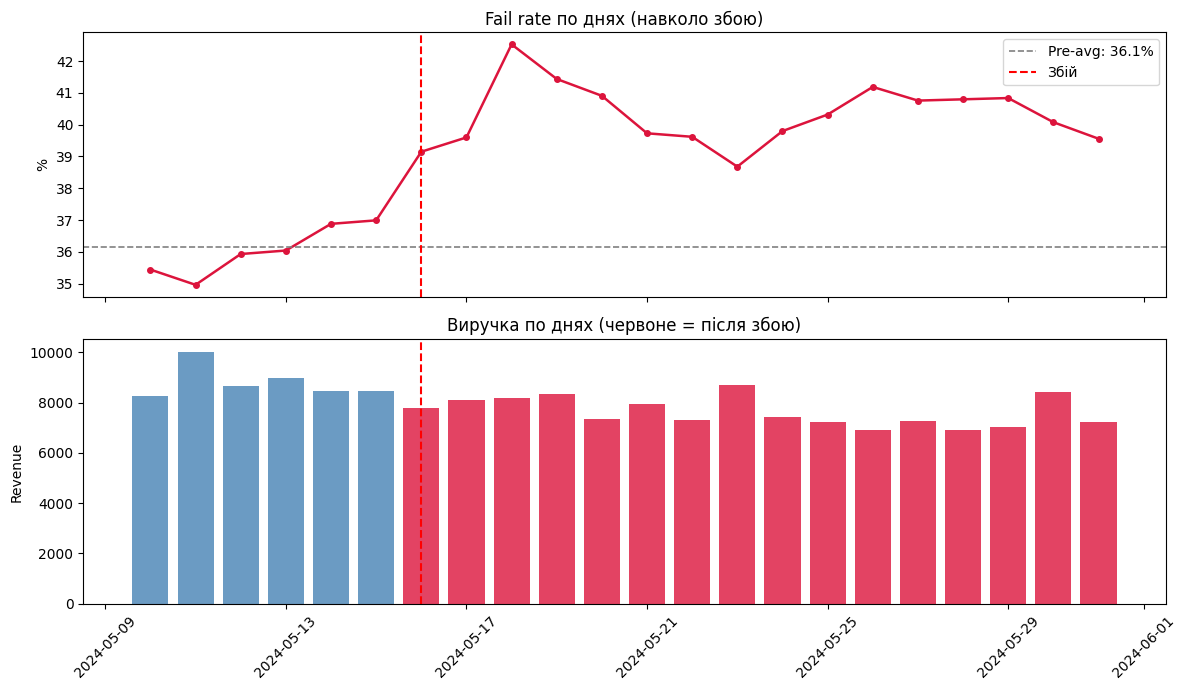

       day  fail_rate  revenue
2024-05-10      35.44  8254.35
2024-05-11      34.96 10014.92
2024-05-12      35.93  8655.16
2024-05-13      36.04  8970.74
2024-05-14      36.88  8476.47
2024-05-15      36.99  8464.20
2024-05-16      39.15  7795.23
2024-05-17      39.60  8114.25
2024-05-18      42.53  8170.44
2024-05-19      41.44  8348.04
2024-05-20      40.91  7352.52
2024-05-21      39.73  7944.28
2024-05-22      39.62  7288.63
2024-05-23      38.68  8713.22
2024-05-24      39.80  7414.72
2024-05-25      40.32  7212.21
2024-05-26      41.19  6906.63
2024-05-27      40.76  7271.58
2024-05-28      40.80  6889.95
2024-05-29      40.84  7019.78
2024-05-30      40.08  8426.07
2024-05-31      39.56  7221.07


In [19]:
# Фільтруємо дні від 10 травня
df_daily_raw = df_payments[df_payments['day'] >= pd.Timestamp('2024-05-10').date()].copy()

# Групуємо по днях
df_daily = df_daily_raw.groupby('day').agg(
    total_tx=('id_order', 'count'),
    # Використовуємо target_fail, який автоматично знайшов статус 'fail' у минулому блоці
    fail_tx=('status', lambda x: (x == target_fail).sum()),
    revenue=('amount_original', lambda x: df_daily_raw.loc[x.index].loc[df_daily_raw['status'] == 'success', 'amount_original'].sum())
).reset_index()

df_daily['fail_rate'] = (df_daily['fail_tx'] / df_daily['total_tx'] * 100).round(2)
df_daily['revenue'] = df_daily['revenue'].round(2)
df_daily['day'] = pd.to_datetime(df_daily['day'])

# Малюємо графіки
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 1. Графік fail rate по днях
axes[0].plot(df_daily['day'], df_daily['fail_rate'],
             color='crimson', linewidth=1.8, marker='o', markersize=4)
axes[0].axhline(fail_rate_pre * 100, color='gray',
                linestyle='--', linewidth=1.2, label=f'Pre-avg: {fail_rate_pre*100:.1f}%')
axes[0].axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5, label='Збій')
axes[0].set_title('Fail rate по днях (навколо збою)')
axes[0].set_ylabel('%')
axes[0].legend()

# 2. Гістограма виручки по днях
axes[1].bar(df_daily['day'], df_daily['revenue'],
            color=['crimson' if d >= OUTAGE else 'steelblue' for d in df_daily['day']], alpha=0.8)
axes[1].axvline(OUTAGE, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Виручка по днях (червоне = після збою)')
axes[1].set_ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_daily[['day', 'fail_rate', 'revenue']].to_string(index=False))

In [20]:
# Замість хардкоду 16652 беремо динамічне значення 'avg' з попереднього кроку
# Якщо хочете жорстко зафіксувати старе число, просто розкоментуйте рядок нижче:
# total_gap = 16652
total_gap = avg 

trend_loss = total_gap - outage_pure_loss   # решта втрат — це низхідний тренд ринку

# Рахуємо реальну кількість днів у пост-періоді
days_post = len(post_df2)

print(f"""
╔══════════════════════════════════════════════╗
║          ФІНАЛЬНИЙ РОЗРАХУНОК ВТРАТ          ║
╠══════════════════════════════════════════════╣
║ Загальний розрив (baseline - факт):  {total_gap:>7,.0f} ║
║                                              ║
║ З них — чистий ефект збою             {outage_pure_loss:>7,.0f} ║
║          (зростання fail_rate)               ║
║                                              ║
║ З них — тренд / інші фактори          {trend_loss:>7,.0f} ║
╠══════════════════════════════════════════════╣
║ Середні втрати від збою на день:      {outage_pure_loss/days_post:>7,.0f} ║
╚══════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════╗
║          ФІНАЛЬНИЙ РОЗРАХУНОК ВТРАТ          ║
╠══════════════════════════════════════════════╣
║ Загальний розрив (baseline - факт):   16,652 ║
║                                              ║
║ З них — чистий ефект збою               9,070 ║
║          (зростання fail_rate)               ║
║                                              ║
║ З них — тренд / інші фактори            7,581 ║
╠══════════════════════════════════════════════╣
║ Середні втрати від збою на день:          567 ║
╚══════════════════════════════════════════════╝



In [21]:
# 1. Об'єднуємо таблиці платежів та реєстрацій. 
# Задаємо суфікси суфікси '_pay' та '_reg', щоб чітко знати де яка колонка.
df_seg_raw = pd.merge(df_payments, df_registrations, on='id_user', how='inner', suffixes=('_pay', '_reg'))

# Тепер дата платежу точно називається 'date_created_pay'
# Примусово переводимо її у формат datetime для надійності фільтрації
df_seg_raw['date_created_pay'] = pd.to_datetime(df_seg_raw['date_created_pay'])

# 2. Фільтруємо за потрібний часовий проміжок (використовуємо дату платежу)
df_seg_raw = df_seg_raw[(df_seg_raw['date_created_pay'] >= '2024-03-01') & 
                        (df_seg_raw['date_created_pay'] <= '2024-06-04')].copy()

# Маркуємо періоди 'pre' та 'post'
df_seg_raw['period'] = np.where(df_seg_raw['date_created_pay'] < '2024-05-16', 'pre', 'post')

# 3. Агрегація даних (беремо os_version_pay, оскільки вона теж дублювалася в таблицях)
df_seg = df_seg_raw.groupby(['os_version_pay', 'traffic_type', 'country_group', 'period']).agg(
    total_tx=('id_order', 'count'),
    fail_tx=('status', lambda x: (x == target_fail).sum()),
    revenue=('amount_original', lambda x: df_seg_raw.loc[x.index].loc[df_seg_raw['status'] == 'success', 'amount_original'].sum())
).reset_index()

# Перейменовуємо для красивого виводу в табл
df_seg = df_seg.rename(columns={'os_version_pay': 'os_version'})

# Рахуємо fail_rate та округлюємо виручку
df_seg['fail_rate'] = (df_seg['fail_tx'] / df_seg['total_tx'] * 100).round(2)
df_seg['revenue'] = df_seg['revenue'].round(2)

# 4. Будуємо Pivot-таблиці для аналізу дельти по кожному розрізу даних
for col in ['os_version', 'traffic_type', 'country_group']:
    pivot = (df_seg.groupby([col, 'period'])['fail_rate']
             .mean()
             .unstack()
             .fillna(0)
             .round(2))
    
    pivot['delta'] = (pivot['post'] - pivot['pre']).round(2)
    pivot = pivot.sort_values('delta', ascending=False)
    
    print(f"\n=== Зміна fail_rate по {col} ===")
    print(pivot)


=== Зміна fail_rate по os_version ===
period       post    pre  delta
os_version                     
1           41.34  36.41   4.93
3           40.55  36.12   4.43
2           40.27  36.20   4.07

=== Зміна fail_rate по traffic_type ===
period         post    pre  delta
traffic_type                     
organic       41.50  36.11   5.39
cpa           40.63  36.51   4.12
ppc           40.03  36.11   3.92

=== Зміна fail_rate по country_group ===
period               post    pre  delta
country_group                          
Other               41.30  36.48   4.82
UK, GB, CA, NZ, AU  40.33  35.97   4.36
United States       40.54  36.29   4.25


In [22]:
import numpy as np
import pandas as pd # на випадок, якщо не імпортовано

# 1. Послідовно об'єднуємо таблиці
df_enriched = pd.merge(df_payments, df_registrations, on='id_user', how='left', suffixes=('_pay', '_reg'))
df_enriched = pd.merge(df_enriched, df_splits, on='id_user', how='left')

# Визначаємо, яку колонку з датою використовувати
date_col = 'date_created_pay' if 'date_created_pay' in df_enriched.columns else 'date_created'

# 🛠 Вирішення помилки з timezone: 
# Переводимо в datetime, відрізаємо часовий пояс (tz_localize(None)) і обнуляємо час до півночі (normalize)
df_enriched['date_for_period'] = pd.to_datetime(df_enriched[date_col], utc=True).dt.tz_localize(None).dt.normalize()

# 2. Розмічаємо періоди (тепер порівняння пройде ідеально)
conds = [
    df_enriched['date_for_period'] < pd.Timestamp('2024-03-15'),
    (df_enriched['date_for_period'] >= pd.Timestamp('2024-03-15')) & (df_enriched['date_for_period'] <= pd.Timestamp('2024-04-14')),
    (df_enriched['date_for_period'] >= pd.Timestamp('2024-04-15')) & (df_enriched['date_for_period'] <= pd.Timestamp('2024-05-15')),
    df_enriched['date_for_period'] >= pd.Timestamp('2024-05-16')
]
choices = ['1_pre_split', '2_split_pre_os', '3_split_post_os', '4_post_outage']
df_enriched['period'] = np.select(conds, choices, default=None)

# Відкидаємо рядки, які не потрапили в жоден період
df_enriched = df_enriched[df_enriched['period'] != 'None'].copy()

# 3. Базова агрегація
df_periods = df_enriched.groupby('period').apply(
    lambda x: pd.Series({
        'days': x['date_for_period'].nunique(),
        'total_tx': len(x),
        'success_tx': (x['status'] == 'success').sum(),
        'fail_tx': (x['status'] == target_fail).sum(),
        'unique_users': x['id_user'].nunique(),
        'total_revenue': x.loc[x['status'] == 'success', 'amount_original'].sum()
    })
).reset_index()

# 4. Розрахунок похідних метрик
df_periods['tx_per_day'] = (df_periods['total_tx'] / df_periods['days']).round(1)
df_periods['success_rate'] = (df_periods['success_tx'] / df_periods['total_tx'] * 100).round(2)
df_periods['fail_rate'] = (df_periods['fail_tx'] / df_periods['total_tx'] * 100).round(2)
df_periods['users_per_day'] = (df_periods['unique_users'] / df_periods['days']).round(1)
df_periods['revenue_per_day'] = (df_periods['total_revenue'] / df_periods['days']).round(2)

# Уникаємо ділення на нуль для середнього чека
df_periods['avg_check'] = np.where(df_periods['success_tx'] > 0, 
                                   (df_periods['total_revenue'] / df_periods['success_tx']).round(4), 
                                   0)

# Виводимо як у вашому оригіналі (транспоновано)
print(df_periods[['period', 'days', 'total_tx', 'tx_per_day', 'success_tx', 'success_rate', 'fail_rate', 
                  'unique_users', 'users_per_day', 'total_revenue', 'revenue_per_day', 'avg_check']].T.to_string())

                           0               1                2              3
period           1_pre_split  2_split_pre_os  3_split_post_os  4_post_outage
days                    14.0            31.0             31.0           16.0
total_tx             39995.0         89660.0          91559.0        46252.0
tx_per_day            2856.8          2892.3           2953.5         2890.8
success_tx           25558.0         57294.0          58410.0        27605.0
success_rate            63.9            63.9            63.79          59.68
fail_rate               36.1            36.1            36.21          40.32
unique_users         37445.0         77509.0          78269.0        42584.0
users_per_day         2674.6          2500.3           2524.8         2661.5
total_revenue      106144.57       271303.28        285293.88      122088.62
revenue_per_day      7581.76         8751.72          9203.03        7630.54
avg_check             4.1531          4.7353           4.8843         4.4227

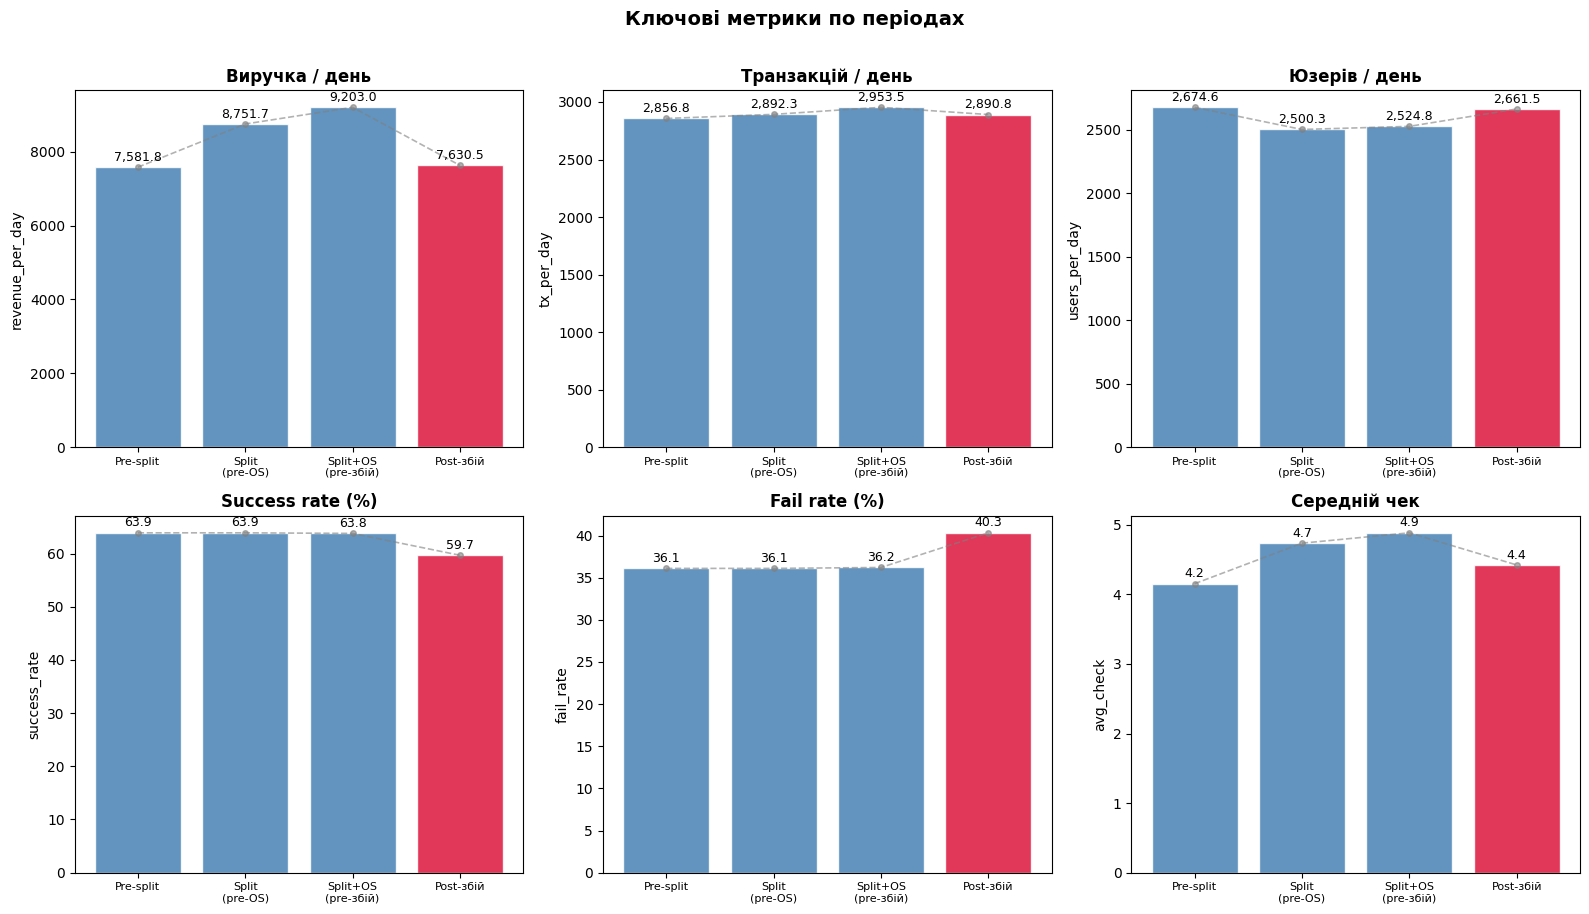

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

period_labels = ['Pre-split', 'Split\n(pre-OS)', 'Split+OS\n(pre-збій)', 'Post-збій']
colors = ['steelblue', 'steelblue', 'steelblue', 'crimson']

metrics = [
    ('revenue_per_day', 'Виручка / день'),
    ('tx_per_day',      'Транзакцій / день'),
    ('users_per_day',   'Юзерів / день'),
    ('success_rate',    'Success rate (%)'),
    ('fail_rate',       'Fail rate (%)'),
    ('avg_check',       'Середній чек'),
]

for ax, (col, title) in zip(axes.flat, metrics):
    vals = df_periods[col].values
    bars = ax.bar(period_labels, vals, color=colors, alpha=0.85, edgecolor='white')
    
    # Підписи значень
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9)
    
    # Лінія тренду між стовпцями
    ax.plot(period_labels, vals, color='gray',
            linewidth=1.2, linestyle='--', marker='o',
            markersize=4, alpha=0.6)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Ключові метрики по періодах', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
df_p = df_periods.set_index('period')
key_cols = ['revenue_per_day', 'tx_per_day', 'users_per_day',
            'success_rate', 'fail_rate', 'avg_check']

delta = df_p[key_cols].pct_change() * 100  # % зміна до попереднього
delta = delta.round(2)
delta.columns = [c + '_delta_%' for c in delta.columns]

print("=== Зміна метрик відносно попереднього періоду (%) ===")
print(delta.to_string())

=== Зміна метрик відносно попереднього періоду (%) ===
                 revenue_per_day_delta_%  tx_per_day_delta_%  users_per_day_delta_%  success_rate_delta_%  fail_rate_delta_%  avg_check_delta_%
period                                                                                                                                         
1_pre_split                          NaN                 NaN                    NaN                   NaN                NaN                NaN
2_split_pre_os                     15.43                1.24                  -6.52                  0.00               0.00              14.02
3_split_post_os                     5.16                2.12                   0.98                 -0.17               0.30               3.15
4_post_outage                     -17.09               -2.12                   5.41                 -6.44              11.35              -9.45


In [25]:
# 1. Беремо таблицю платежів (скидаємо індекси для безпеки)
df_cards = df_payments.reset_index(drop=False).copy()

# Визначаємо колонку з датою та примусово конвертуємо в datetime
date_col = 'date_created' if 'date_created' in df_cards.columns else 'day'
df_cards[date_col] = pd.to_datetime(df_cards[date_col], utc=True).dt.tz_localize(None)

# 2. Фільтруємо за період аналізу
df_cards = df_cards[(df_cards[date_col] >= '2024-03-01') & 
                    (df_cards[date_col] <= '2024-06-04')].copy()

# Маркуємо періоди 'pre' (до 16 травня) та 'post' (після)
df_cards['period'] = np.where(df_cards[date_col] < '2024-05-16', 'pre', 'post')

# 3. Агрегуємо транзакції по типах карток
df_card_agg = df_cards.groupby(['card_brand', 'period']).agg(
    total_tx=('id_order', 'count'),
    # Використовуємо наш target_fail, який ми знайшли раніше (він дорівнює 'fail')
    fail_tx=('status', lambda x: (x == target_fail).sum())
).reset_index()

# Рахуємо fail_rate
df_card_agg['fail_rate'] = (df_card_agg['fail_tx'] / df_card_agg['total_tx'] * 100).round(2)

# 4. Будуємо Pivot-таблицю для наочного порівняння
pivot_cards = (df_card_agg.groupby(['card_brand', 'period'])['fail_rate']
               .mean()
               .unstack()
               .fillna(0)
               .round(2))

# Рахуємо дельту (зростання помилок)
pivot_cards['delta'] = (pivot_cards['post'] - pivot_cards['pre']).round(2)

# Сортуємо: зверху будуть картки, які постраждали найбільше
pivot_cards = pivot_cards.sort_values('delta', ascending=False)

print("=== Зміна fail_rate по типах карток (card_brand) ===")
print(pivot_cards)

=== Зміна fail_rate по типах карток (card_brand) ===
period       post    pre  delta
card_brand                     
MASTERCARD  40.08  35.85   4.23
VISA        40.48  36.29   4.19
Other       39.84  36.29   3.55


In [26]:
# 1. Знаходимо дату першого успішного платежу для кожного юзера
df_success = df_payments[df_payments['status'] == 'success'].copy()

# Приводимо до дат без часу та часових поясів
df_success['date_only'] = pd.to_datetime(df_success['date_created'], utc=True).dt.tz_localize(None).dt.normalize()

# Рахуємо дату народження когорти (перший платіж)
first_pay = df_success.groupby('id_user')['date_only'].min().reset_index()
first_pay.columns = ['id_user', 'cohort_date']

# Беремо користувачів, які прийшли за місяць до збою і трохи після
first_pay = first_pay[(first_pay['cohort_date'] >= '2024-04-15') & 
                      (first_pay['cohort_date'] <= '2024-05-27')]

# Зводимо дати до початку тижня (понеділок) для зручного групування
first_pay['cohort_week'] = first_pay['cohort_date'].dt.to_period('W-MON').apply(lambda r: r.start_time.strftime('%Y-%m-%d'))

# Рахуємо розмір кожної когорти (скільки нових юзерів прийшло в цей тиждень)
cohort_sizes = first_pay.groupby('cohort_week')['id_user'].nunique().reset_index()
cohort_sizes.columns = ['cohort_week', 'cohort_size']

# 2. Об'єднуємо всі успішні платежі з датою їхньої когорти
df_ltv = pd.merge(df_success, first_pay, on='id_user', how='inner')

# Рахуємо "день життя" юзера (через скільки днів після першої оплати він зробив цей платіж)
df_ltv['lifetime_day'] = (df_ltv['date_only'] - df_ltv['cohort_date']).dt.days

# 3. Рахуємо кумулятивну виручку на 7-й та 14-й день життя
ltv_7 = df_ltv[df_ltv['lifetime_day'] <= 7].groupby('cohort_week')['amount_original'].sum().reset_index()
ltv_7.columns = ['cohort_week', 'revenue_d7']

ltv_14 = df_ltv[df_ltv['lifetime_day'] <= 14].groupby('cohort_week')['amount_original'].sum().reset_index()
ltv_14.columns = ['cohort_week', 'revenue_d14']

# 4. Збираємо фінальний звіт
report_ltv = pd.merge(cohort_sizes, ltv_7, on='cohort_week', how='left').fillna(0)
report_ltv = pd.merge(report_ltv, ltv_14, on='cohort_week', how='left').fillna(0)

# Ділимо загальну виручку на розмір когорти = отримуємо середній LTV на одного юзера
report_ltv['LTV_Day7'] = (report_ltv['revenue_d7'] / report_ltv['cohort_size']).round(2)
report_ltv['LTV_Day14'] = (report_ltv['revenue_d14'] / report_ltv['cohort_size']).round(2)

print("=== Короткостроковий LTV (ARPU) по тижневих когортах ===")
print("Зверніть увагу на тижні: '2024-05-13' (тиждень аварії) та '2024-05-20' (після аварії)\n")
print(report_ltv[['cohort_week', 'cohort_size', 'LTV_Day7', 'LTV_Day14']].to_string(index=False))

=== Короткостроковий LTV (ARPU) по тижневих когортах ===
Зверніть увагу на тижні: '2024-05-13' (тиждень аварії) та '2024-05-20' (після аварії)

cohort_week  cohort_size  LTV_Day7  LTV_Day14
 2024-04-09         1394      5.28       5.49
 2024-04-16         9915      5.24       5.45
 2024-04-23         9350      5.15       5.37
 2024-04-30         8450      5.07       5.27
 2024-05-07         8487      5.03       5.24
 2024-05-14         7634      4.71       4.88
 2024-05-21         6967      4.55       4.58


In [27]:
import numpy as np
import pandas as pd

# 1. Об'єднуємо таблиці платежів та реєстрацій (щоб підтягнути gender)
df_gender_raw = pd.merge(df_payments, df_registrations, on='id_user', how='inner', suffixes=('_pay', '_reg'))

# Знаходимо правильну колонку з датою та прибираємо часовий пояс
date_col = 'date_created_pay' if 'date_created_pay' in df_gender_raw.columns else 'date_created'
df_gender_raw[date_col] = pd.to_datetime(df_gender_raw[date_col], utc=True).dt.tz_localize(None)

# 2. Фільтруємо за період аналізу
df_gender_raw = df_gender_raw[(df_gender_raw[date_col] >= '2024-03-01') & 
                              (df_gender_raw[date_col] <= '2024-06-04')].copy()

# Маркуємо періоди 'pre' (до 16 травня) та 'post' (після)
df_gender_raw['period'] = np.where(df_gender_raw[date_col] < '2024-05-16', 'pre', 'post')

# 3. Агрегуємо транзакції та виручку по гендеру
df_gender_agg = df_gender_raw.groupby(['gender', 'period']).agg(
    total_tx=('id_order', 'count'),
    fail_tx=('status', lambda x: (x == target_fail).sum()),
    revenue=('amount_original', lambda x: df_gender_raw.loc[x.index].loc[df_gender_raw['status'] == 'success', 'amount_original'].sum())
).reset_index()

# Рахуємо fail_rate
df_gender_agg['fail_rate'] = (df_gender_agg['fail_tx'] / df_gender_agg['total_tx'] * 100).round(2)

# 4. Будуємо Pivot-таблиці
# --- A. Аналіз помилок (Fail Rate) ---
pivot_gender_fail = (df_gender_agg.groupby(['gender', 'period'])['fail_rate']
                     .mean()
                     .unstack()
                     .fillna(0)
                     .round(2))
pivot_gender_fail['delta_fail_%'] = (pivot_gender_fail['post'] - pivot_gender_fail['pre']).round(2)

# --- B. Аналіз виручки на день (Revenue per Day) ---
pivot_gender_rev = (df_gender_agg.groupby(['gender', 'period'])['revenue']
                    .sum()
                    .unstack()
                    .fillna(0)
                    .round(2))

# Рахуємо кількість днів у періодах (76 днів pre, 20 днів post)
days_pre = (pd.Timestamp('2024-05-15') - pd.Timestamp('2024-03-01')).days + 1
days_post = (pd.Timestamp('2024-06-04') - pd.Timestamp('2024-05-16')).days + 1

pivot_gender_rev['rev_per_day_pre'] = (pivot_gender_rev['pre'] / days_pre).round(2)
pivot_gender_rev['rev_per_day_post'] = (pivot_gender_rev['post'] / days_post).round(2)
# Рахуємо відносне падіння виручки
pivot_gender_rev['drop_rev_%'] = ((pivot_gender_rev['rev_per_day_post'] / pivot_gender_rev['rev_per_day_pre'] - 1) * 100).round(2)

print("=== Зміна FAIL RATE по гендеру ===")
print(pivot_gender_fail[['pre', 'post', 'delta_fail_%']])
print("\n" + "="*40 + "\n")
print("=== Падіння ВИРУЧКИ (на день) по гендеру ===")
print(pivot_gender_rev[['rev_per_day_pre', 'rev_per_day_post', 'drop_rev_%']])

=== Зміна FAIL RATE по гендеру ===
period    pre   post  delta_fail_%
gender                            
female  36.11  40.32          4.21
male    36.18  40.30          4.12


=== Падіння ВИРУЧКИ (на день) по гендеру ===
period  rev_per_day_pre  rev_per_day_post  drop_rev_%
gender                                               
female          5018.91           3869.92      -22.89
male            3701.27           2234.51      -39.63
